In [840]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [842]:
data = pd.read_csv("data/Data.csv")

In [844]:
data.head()

,Time (s),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.017904,0.261416,10.021141,1.597807,10.151088
1,0.020055,0.251845,10.021141,1.583450,10.148596
2,0.022210,0.242273,10.025927,1.588236,10.153836
3,0.024368,0.232702,10.030712,1.564308,10.154624
4,0.026524,0.232104,10.025927,1.540380,10.146223


#### Since we are only looking for the acceleration in the Y axis we can remove the Acceleration x (m/s^2)	Acceleration Z (m/s^2) column from our data 

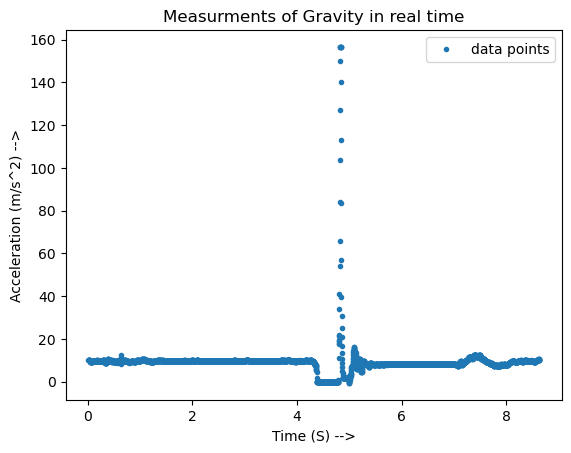

In [847]:
data = data[["Time (s)", "Acceleration y (m/s^2)"]]
plt.errorbar(data.iloc[:, 0], data.iloc[:, 1], fmt=".", label="data points")
plt.xlabel("Time (S) -->"); plt.ylabel("Acceleration (m/s^2) -->")
plt.legend()
plt.title("Measurments of Gravity in real time")
pass


#### Since it is much easier to work with zero we are going to subtract the estimated graviy form our data points from all the data. 
#### To subtract gravity we get the data points before the free fall and use curve fit to estimate gravity


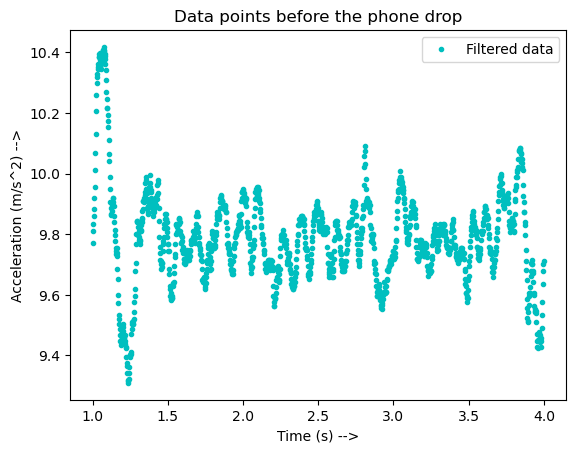

In [850]:
# Filters the data frame

data_line_fit = data[(data["Time (s)"] > 1) & (data["Time (s)"] < 4)]
plt.errorbar(data_line_fit.iloc[:, 0], data_line_fit.iloc[:, 1], fmt=".", label="Filtered data", c="c")
plt.xlabel("Time (s) -->"); plt.ylabel("Acceleration (m/s^2) -->")
plt.title("Data points before the phone drop")
plt.legend()
pass

In [852]:
# Using scipy.optimize.curvefit to estimate the gravity from data collection

linear_model = lambda x, a, b: a * x + b
parameters, cov = curve_fit(linear_model, data_line_fit.iloc[:, 0], data_line_fit.iloc[:, 1])
gravity = parameters[1]
std_error = np.std(data["Acceleration y (m/s^2)"], ddof=1) / np.sqrt(len(data))
print(f"gravity = {gravity:.2g}\nuncertainity = {std_error:.2g}")

gravity = 9.8
uncertainity = 0.12


$$ \text{Estimated gravity} = 9.8 \pm 0.12 \, \text{m/s}^2 $$

##### Now we subtract the gravity from all the data sets

In [856]:
data["Acceleration y (m/s^2)"] = data["Acceleration y (m/s^2)"] - gravity

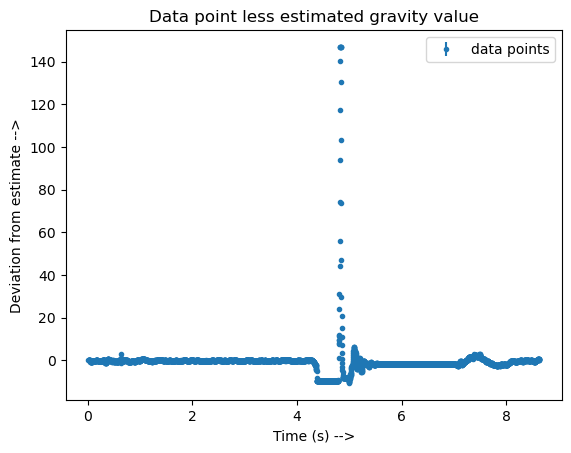

In [858]:
plt.errorbar(data.iloc[:, 0], data.iloc[:, 1], fmt=".", label="data points", yerr=std_error)
plt.xlabel("Time (s) -->"); plt.ylabel("Deviation from estimate -->")
plt.title("Data point less estimated gravity value")
plt.legend()
pass

In [860]:
velocities = []     # Make an empty list where we will store our newly calculate velocities

# This goes through every row of data one by one. 
# The for loop goes from the first element of the data table to the last, with the size 
# given by the length of the data["time"] row (data["time"].size). That is, i=0, 1, 2, ..., (length of the table)
for i in range(data["Time (s)"].size): 
    
    # Here I am selecting multiple rows and ALL columns, up to the i-th row
    data_up_to_this_row = data.head(i)
    
    # Now, get the x- and y-values for the integral from our slice of data
    ts  = data_up_to_this_row["Time (s)"]
    acc = data_up_to_this_row["Acceleration y (m/s^2)"] 
    
    # Calculate the integral
    v   = np.trapz(acc, ts)
    
    # Finally, add the new velocity to the velocity list
    velocities.append(v)    
    
# Make a new column in the data frame to store the velocities
data["Velocity (m/s)"] = velocities

In [865]:
position = []     # Make an empty list where we will store our newly calculate velocities

# This goes through every row of data one by one. 
# The for loop goes from the first element of the data table to the last, with the size 
# given by the length of the data["time"] row (data["time"].size). That is, i=0, 1, 2, ..., (length of the table)
for i in range(data["Time (s)"].size): 
    
    # Here I am selecting multiple rows and ALL columns, up to the i-th row
    data_up_to_this_row = data.head(i)
    
    # Now, get the x- and y-values for the integral from our slice of data
    ts  = data_up_to_this_row["Time (s)"]
    acc = data_up_to_this_row["Velocity (m/s)"] 
    
    # Calculate the integral
    v   = np.trapz(acc, ts)
    
    # Finally, add the new velocity to the velocity list
    position.append(v)    
    
# Make a new column in the data frame to store the velocities
data["position (m)"] = position


### Now we plot the graph on our free fall interval to get an estimate for the hight

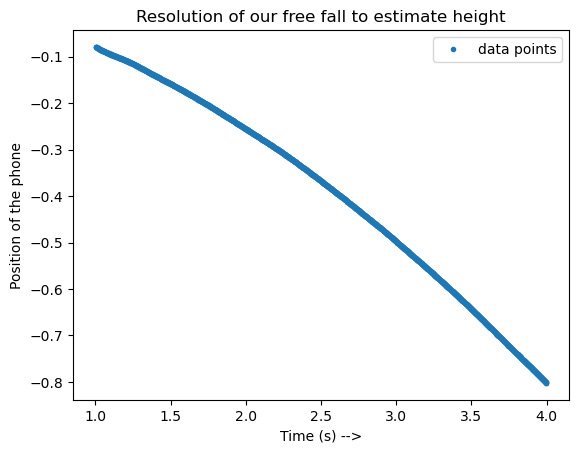

In [868]:
# First creates a data frame of time and position 
# Then filters it to our free fall period
# Finally plots the position graph to show our results
positions = pd.DataFrame()
positions["Time (s)"] = data["Time (s)"]
positions["Positions (m)"] = position

# Filters position on our free fall interval
free_fall = positions[(data["Time (s)"] > 1) & (positions["Time (s)"] < 4)]

# plots our result
plt.errorbar(free_fall.iloc[:, 0], free_fall.iloc[:, 1], fmt=".", label="data points")
plt.xlabel("Time (s) -->"); plt.ylabel("Position of the phone")
plt.title("Resolution of our free fall to estimate height")
plt.legend()
pass



## We can see that our phone was droped from a height of -.1 meters and traveld to positon -.8 meaning from our data points we can conclude that our data traveled a distance of 0.9 meters during the free fall

$$ \text{Height} = 0.9 \pm 0.15 \, \text{meters} $$

# Dominant source of uncertainity:

### The dominant of uncertainity is us moving the phone before dropping it. From the plot of the position we can see that we didn't release the phone quickly but rather gave it a little throw up to release it

# Comparison:

## we droped our phone from approximately 1 meters and our results from the estimates matches well with the actual height. As the true value for the height (1 m) falls between the our estimate and associated uncertainity

# Connection to physics:

# Our data points alligns from what we expect from the physical world because 
### 1. The phone sensors measured the phone being weight less during the free fall
### 2. The velocity of our data points increases linearly during free fall
### 3. The position changes some what quadratically


# Part 2: ----------------- Measuring the acceleration while going up an elevator from first floor to third floor in bloomberg

In [876]:
data = pd.read_csv("data/Raw Data.csv")

In [878]:
data.head()

,Time (s),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.014874,-0.084347,0.253041,9.756734,9.760379
1,0.017031,-0.093918,0.233898,9.728021,9.731285
2,0.019190,-0.099302,0.267398,9.699904,9.704098
3,0.021346,-0.084347,0.262612,9.737592,9.741497
4,0.023503,-0.089133,0.272184,9.751948,9.756153


#### Since we are only looking for the acceleration in the Z axis we can remove the Acceleration x (m/s^2)	Acceleration Y (m/s^2) column from our data 

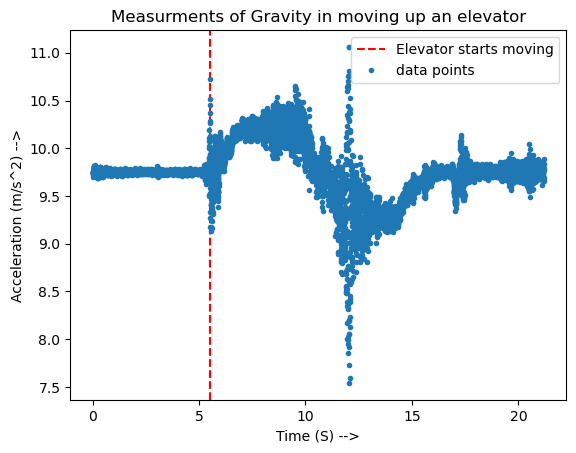

In [881]:
data = data[["Time (s)", "Acceleration z (m/s^2)"]]
plt.errorbar(data.iloc[:, 0], data.iloc[:, 1], fmt=".", label="data points")
plt.xlabel("Time (S) -->"); plt.ylabel("Acceleration (m/s^2) -->")
plt.axvline(x=5.5, color='r', linestyle="--", label="Elevator starts moving")
plt.legend()
plt.title("Measurments of Gravity in moving up an elevator")
pass


# Answer to the maximum acceleration of the elevator >>>

# We know that the acceleration of the elevator and the phone in equal. To get the maximum acceleration we first need to filter our anomaly data points

#### Since it's much easier to work with zero we are going to subtract the estimated graviy form our data points from all the data.To subtract gravity we get the data points before the elevator starts moving and use curve fit to estimate gravity. To do that we calculate the z score (How many standard deviations away the data point are from the mean)

In [888]:
data['zscore'] = (data["Acceleration z (m/s^2)"] - data["Acceleration z (m/s^2)"].mean()) / data["Acceleration z (m/s^2)"].std()

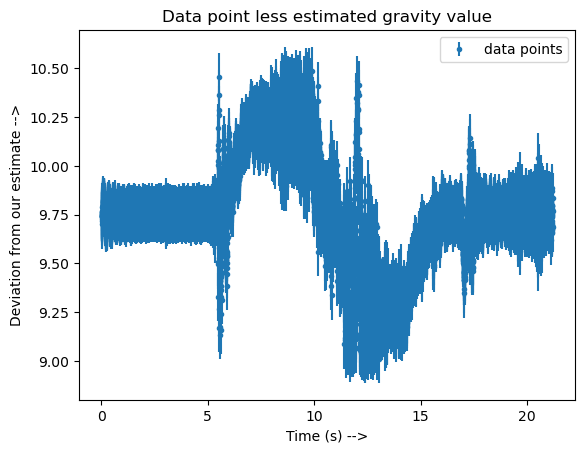

In [890]:
# Filter out points where the z-score is less than 3
data_filtered = data[np.abs(data['zscore']) < 2.5]

plt.errorbar(data_filtered.iloc[:, 0], data_filtered.iloc[:, 1], fmt=".", label="data points", yerr=std_error)
plt.xlabel("Time (s) -->"); plt.ylabel("Deviation from our estimate -->")
plt.title("Data point less estimated gravity value")
plt.legend()
pass


In [892]:
std_error = np.std(data_filtered["Acceleration z (m/s^2)"], ddof=1) / np.sqrt(len(data_filtered))
print("Max acceleration =", round(max(data_filtered["Acceleration z (m/s^2)"]), 1))
print("Uncertainity =", round(std_error, 3))

Max acceleration = 10.5
Uncertainity = 0.003


$$
\text{The measured maximum acceleration for the evator is } 10.500 \pm 0.003 \, \text{m/s}^2.
$$

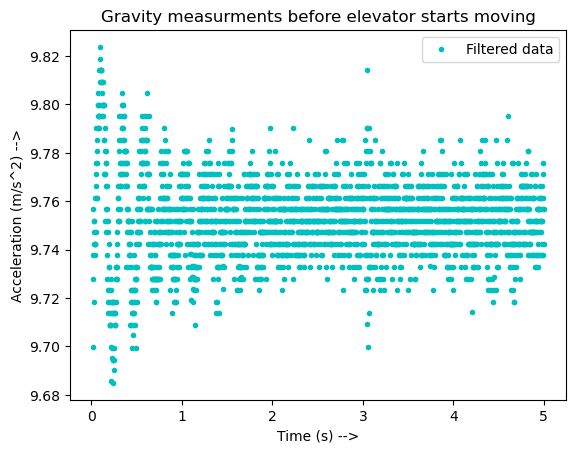

In [895]:


# Filters the data frame

data_line_fit = data[(data["Time (s)"] < 5)]
plt.errorbar(data_line_fit.iloc[:, 0], data_line_fit.iloc[:, 1], fmt=".", label="Filtered data", c="c")
plt.xlabel("Time (s) -->"); plt.ylabel("Acceleration (m/s^2) -->")
plt.title("Gravity measurments before elevator starts moving")
plt.legend()
pass

In [897]:
# Using scipy.optimize.curvefit to estimate the gravity from data collection

linear_model = lambda x, a, b: a * x + b
parameters, cov = curve_fit(linear_model, data_line_fit.iloc[:, 0], data_line_fit.iloc[:, 1])
gravity = parameters[1]
std_error = np.std(data["Acceleration z (m/s^2)"], ddof=1) / np.sqrt(len(data))
print(f"gravity = {gravity:.2g}\nuncertainity = {std_error:.1g}")


gravity = 9.8
uncertainity = 0.003


$$ \text{Estimated gravity} = 9.8 \pm 0.003 \, \text{m/s}^2 $$

#### Now we subtract the gravity from all the data sets and plot our results

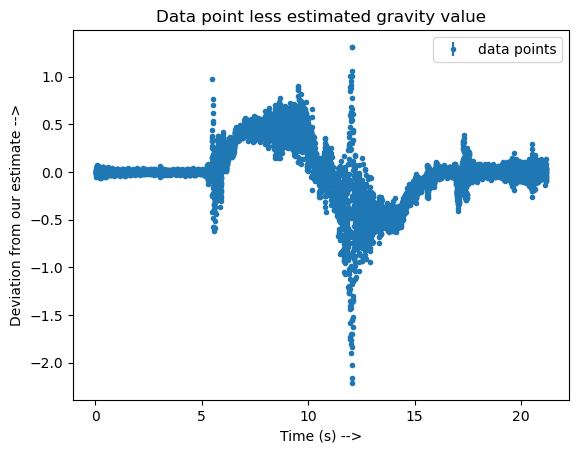

In [901]:
data["Acceleration z (m/s^2)"] = data["Acceleration z (m/s^2)"] - gravity

plt.errorbar(data.iloc[:, 0], data.iloc[:, 1], fmt=".", label="data points", yerr=std_error)
plt.xlabel("Time (s) -->"); plt.ylabel("Deviation from our estimate -->")
plt.title("Data point less estimated gravity value")
plt.legend()
pass


# Now we plot our velocty verses time graph for the phones jorney in the elevator

In [904]:
velocities = []     # Make an empty list where we will store our newly calculate velocities

# This goes through every row of data one by one. 
# The for loop goes from the first element of the data table to the last, with the size 
# given by the length of the data["time"] row (data["time"].size). That is, i=0, 1, 2, ..., (length of the table)
for i in range(data["Time (s)"].size): 
    
    # Here I am selecting multiple rows and ALL columns, up to the i-th row
    data_up_to_this_row = data.head(i)
    
    # Now, get the x- and y-values for the integral from our slice of data
    ts  = data_up_to_this_row["Time (s)"]
    acc = data_up_to_this_row["Acceleration z (m/s^2)"] 
    
    # Calculate the integral
    v   = np.trapz(acc, ts)
    
    # Finally, add the new velocity to the velocity list
    velocities.append(v)    
    
# Make a new column in the data frame to store the velocities
data["Velocity (m/s)"] = velocities

## We now plot our velocity vs time graph to get the maximum velocity and how long it takes for the elevator to get to v max

In [906]:
velocity = pd.DataFrame()
velocity["Time (s)"] = data["Time (s)"]
velocity["velocity (m/s)"] = velocities

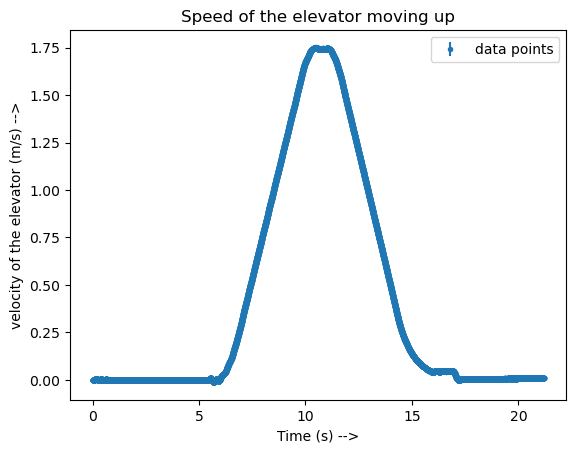

In [909]:
# plots our result
plt.errorbar(velocity.iloc[:, 0], velocity.iloc[:, 1], fmt=".", label="data points", yerr=std_error)
plt.xlabel("Time (s) -->"); plt.ylabel("velocity of the elevator (m/s) -->")
plt.title("Speed of the elevator moving up")
plt.legend()

In [910]:
v_max = np.max(velocity["velocity (m/s)"])
print(f"Maximum velocity = {round(v_max, 1)}")

Maximum velocity = 1.8


# Answer for maximum velocity of the elevator >>>

$$
\text{The measured maximum velocity for the evator is } 1.8 \pm 0.003 \, \text{m/s}.
$$

## To get the maximum time it takes the elevator to reach maximum speed we get the index of h_max

In [916]:
index_position = velocity['velocity (m/s)'].eq(v_max).idxmax()
time_interval = data.iloc[1, 0] - data.iloc[0,0]
print(f"Time before v_max = {data.iloc[index_position, 0]:.5g}")
print(f"Uncertainity = {time_interval:.1g}")


Time before v_max = 10.476
Uncertainity = 0.002


$$
\text{Time before } h_{\text{max}} = 10.476 \pm 0.002 \, \text{seconds}
$$


# Dominant source of uncertainity:
# The dominant of uncertainity is the vibrations the elevator expierienced during its time of movement. Closing of doors and just random vibrations that occur when moving up

# Connection to Physics

### Our results alligns with the expected from the pysical world because the elevator first experienced acceleration and then deceleration after reaching v max before stopping at last (reaching the third floor)


# comparison:
# Even though we don't know the exact speed and acceleration of the elevator we can check that our graphs behave as expected and it does. That is because from the graph we see the ball accelerating and then decelerating before finally coming to rest